In [1]:
# import block
import json
import pandas as pd
import pprint
import xml.etree.ElementTree as ET
import time
import xmltodict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Fairsharing

Queried FAIRsharing API to retrieve all records (5,000+) in JSON format. 

Last run date: 10.04.2026

In [2]:
with open("data/fairsharing_records_all.json", "r") as f:
    records_all = json.load(f)

## Filtering


### Step 1: Functional filtering

Applying a two-stage functional filter:

- **Database filter:** filter for records categorized as `registry → database`
    - excludes records like metadata standards, journal policies, and general collections


- **Repository type filter:** narrow the results further to `record type → repository`
    - includes "pure" repositories and hybrid "knowledgebase and repository" entries
    - excludes "knowledgebase-only" entries

In [3]:
filtered_repositories = []

for rec in records_all:
    attrs = rec.get("attributes", {})
    
    if (
        attrs.get("fairsharing_registry") == "Database"
        and attrs.get("record_type") == "repository"
    ):
        filtered_repositories.append(rec)

print(f"Repositories found: {len(filtered_repositories)}") # 1736 repos found, which is the exact same number as on the website for the same filters

pprint.pprint(filtered_repositories[10]) # inspecting record


Repositories found: 1736
{'attributes': {'abbreviation': None,
                'countries': ['Canada'],
                'created_at': '2026-03-12T12:50:58.871Z',
                'description': 'This FAIRsharing record describes: The City of '
                               'Burlington Open Data makes city data available '
                               'for public use and new application '
                               'development. ',
                'doi': None,
                'domains': [],
                'exhaustive_licences': False,
                'fairsharing_licence': 'https://creativecommons.org/licenses/by-sa/4.0/. '
                                       'Please link to https://fairsharing.org '
                                       'and '
                                       'https://api.fairsharing.org/img/fairsharing-attribution.svg '
                                       'for attribution.',
                'fairsharing_registry': 'Database',
                'grant

### Step 2: Thematic filtering


**Exploring further attributes:**

- useful fields/ categories could be 'domains', 'subjects' and 'taxonomies'

- check unique values and counts of these to help decide what to filter for

Saving output as .txt file.

In [4]:
with open("output/categorical_counts.txt", "w") as f:
    
    fields_to_check = ['domains', 'user_defined_tags', 'subjects', 'taxonomies']

    for field in fields_to_check:
        counts = {}
        for rec in filtered_repositories:
            items = rec.get("attributes", {}).get(field, [])
            for item in items:
                counts[item] = counts.get(item, 0) + 1

        sorted_items = sorted(counts.items(), key=lambda x: x[1], reverse=True)

        # save list to text file
        f.write(f"\n--- {field.upper()} ---\n")
        f.write(f"Total Unique: {len(counts)}\n")
        for name, count in sorted_items:
            f.write(f"{name}: {count}\n")

        # print summary
        print(f"\n--- {field.upper()} ---")
        print(f"Total Unique: {len(counts)}")
        for name, count in sorted_items[:10]:
            print(f"{name}: {count}")


--- DOMAINS ---
Total Unique: 420
climate: 121
marine environment: 69
genome: 66
data storage: 65
Expression data: 49
disease: 48
Taxonomic classification: 45
FAIR: 45
protein: 44
gene: 42

--- USER_DEFINED_TAGS ---
Total Unique: 437
institutional repository: 225
COVID-19: 83
Geospatial Data: 63
Geographic Information System (GIS): 58
Observations: 32
urban science: 27
earth observation: 26
Dashboard: 26
Climate change: 24
digital humanities: 19

--- SUBJECTS ---
Total Unique: 375
Life Science: 333
Earth Science: 270
Subject Agnostic: 247
Environmental Science: 199
Biomedical Science: 162
Social Science: 113
Oceanography: 110
Clinical Studies: 109
Genomics: 106
Atmospheric Science: 102

--- TAXONOMIES ---
Total Unique: 356
Not applicable: 751
All: 464
Homo sapiens: 332
Mus musculus: 67
SARS-CoV-2: 41
Bacteria: 26
Plantae: 23
Rattus norvegicus: 20
Fungi: 20
Eukaryota: 17


In [5]:
def print_value_counts(records, field):
    counts = {}

    for rec in records:
        attrs = rec.get("attributes", {})
        for v in attrs.get(field, []):
            counts[v] = counts.get(v, 0) + 1

    print(f"\n--- {field.upper()} ---")
    for v, c in sorted(counts.items(), key=lambda x: x[1], reverse=True):
        print(f"{v}: {c}")


fields_to_check = ['domains', 'user_defined_tags', 'subjects', 'taxonomies']


''' 
for field in fields_to_check:
     print_value_counts(filtered_repositories, field)
'''

' \nfor field in fields_to_check:\n     print_value_counts(filtered_repositories, field)\n'

#### Keyword search

Look for all the ways COVID-19 is mentioned under domains, user defined tags, taxonomies **and** in the descriptions by searching for 'cov' and 'corona':

In [6]:
# keywords to search for
search_terms = ["cov", "corona"]

# dictionary for all unique matches
potential_filters = {
    "domains": set(),
    "user_defined_tags": set(),
    "taxonomies": set()
}

for rec in filtered_repositories:
    attrs = rec.get("attributes", {})
    
    for field in potential_filters.keys():
        tags = attrs.get(field, [])
        if isinstance(tags, list):
            for tag in tags:
                if any(term in tag.lower() for term in search_terms):
                    potential_filters[field].add(tag)

# print results
for field, matches in potential_filters.items():
    print(f"\n--- Found in {field.upper()} ---")
    if not matches:
        print("None")
    for match in sorted(matches):
        print(match)


# check descriptions for matches
description_matches = set()

for rec in filtered_repositories:
    desc = rec.get("attributes", {}).get("description", "")
    
    if desc:
        # split the description into individual words to find the specific match
        words = desc.lower().split()
        for word in words:
            # clean punctuation from the word 
            clean_word = "".join(char for char in word if char.isalnum() or char == '-')
            if any(term in clean_word for term in search_terms):
                description_matches.add(clean_word)

print("\n--- Found in DESCRIPTIONS ---")
if not description_matches:
    print("None")
else:
    for match in sorted(description_matches):
        print(match)


--- Found in DOMAINS ---
None

--- Found in USER_DEFINED_TAGS ---
COVID-19

--- Found in TAXONOMIES ---
Coronaviridae
SARS-CoV-2

--- Found in DESCRIPTIONS ---
capacity-covid
coronal
coronavirus
covalent
covariance
cover
coverage
coverages
covered
covering
covers
covid
covid-19
covid-hep
covims
discover
discoverability
discoverable
discovered
discoveries
discovering
discovery
discoverycharacterization
disscover
epicov
hcov-19
httpsenc-supportnudata-aanvraag-meerjarig-long-covid-onderzoek
neurodiscovery
post-covid-19
recover
recoverable
recovered
sars-cov-2
uncover


Define final search terms & filter repositories based on the above results:

In [7]:
# terms for list-based fields (tags & taxonomies)
covid_search_terms = {"COVID-19", "Coronaviridae", "SARS-CoV-2"}

# keywords for searching descriptions
desc_keywords = ["covid", "sars-cov-2", "coronavirus", "2019-ncov"]

covid_repositories = []

for rec in filtered_repositories:
    attrs = rec.get("attributes", {})
    
    # check tags & taxonomies
    tags = attrs.get("user_defined_tags", []) or []
    taxa = attrs.get("taxonomies", []) or []

    # check descriptions
    desc = (attrs.get("description", "") or "").lower()
    
    # match if it's in tags OR taxa OR description
    found_in_metadata = covid_search_terms.intersection(set(tags + taxa))
    found_in_desc = any(term in desc for term in desc_keywords)
    
    if found_in_metadata or found_in_desc:
        covid_repositories.append(rec)

print(f"Total COVID-19 repositories identified: {len(covid_repositories)}")

Total COVID-19 repositories identified: 84


#### Use the COVID dataset to look for other similar repositories

**Idea:** check domains, user_defined_tags, subjects, and taxonomies **of the covid repositories** and use those to define what categories to filter for. 

-> Meaning, repositories that host COVID-19 data could be in similar subject categories, have similar tags or taxonomies but not necessarily be tagged as 'COVID-19'.

In [8]:
''' 
for field in fields_to_check:
    print_value_counts(covid_repositories, field)
'''

' \nfor field in fields_to_check:\n    print_value_counts(covid_repositories, field)\n'

**Subjects with at least 5 counts:** 
- Epidemiology: 46
- Clinical Studies: 42
- Health Science: 36
- Medical Virology: 36
- Infectious Disease Medicine: 28
- Medicine: 27
- Virology: 22
- Biomedical Science: 16
- Critical Care Medicine: 15
- Life Science: 12
- Public Health: 10
- Genomics: 8
- Microbiology: 5
- Social Science: 5


**Test:** let's see how many hits we get when filtering for these subject categories only (without covid keywords)

In [9]:
# extract subjects that have at least 5 counts and store them in a list
counts = {}
for rec in covid_repositories:
    attrs = rec.get("attributes", {})
    for v in attrs.get("subjects", []):
        counts[v] = counts.get(v, 0) + 1

popular_subjects = [subject for subject, count in counts.items() if count >= 5]

# print(len(popular_subjects)) 
# print(popular_subjects)

popular_subjects_set = set(popular_subjects)

subject_repos = []

for rec in filtered_repositories:
    # get the subjects for the current record
    attrs = rec.get("attributes", {})
    record_subjects = attrs.get("subjects", [])
    
    # check if ANY subject in record is in the 'popular' list
    if any(s in popular_subjects_set for s in record_subjects):
        subject_repos.append(rec)

print(f"Original count: {len(filtered_repositories)}")
print(f"Covid count: {len(covid_repositories)}")
print(f"Refined count (based on subjects): {len(subject_repos)}")

Original count: 1736
Covid count: 84
Refined count (based on subjects): 747


**CONCLUSION:** 

If we were to look at all repositories that have the same 'subjects' as the identified COVID ones, we would end up with 747 repos. We would need additional levels of filters after this. One way could also be starting to define what to exclude.

... but I'm not convinced, so **another idea:** 

**Search for similarities** across ALL fields/ categories **programmatically**, instead of trying to define them manually!


How it's done: 

**1. The metadata "soup":**

Instead of looking at subjects, tags, or domains separately, I combine all of the information for each repository into one block of text = like a soup.


**2. Identifying the "important" words:**

The idea is that not all words as equally useful or informative. For example, the subject "epidemiology" appears a lot but it's a very broad category and so it might not help distinguishing one repository from another. So what I do is give the terms "weights" in a way that common words are downplayed and rare/ specific terms are highlighted. Specific method: TF-IDF.

**3. Building a "gold standard" COVID repository:**

Then we look at the 84 COVID repositories that we already successfully identified and "take their average" to represent what a typical COVID repository would look like, thereby creating something like a mathematical gold standard.

**4. Similarity scoring**

Finally, we compare every repository in the database to the "gold standard" profile. This gives us similarity scores between 0 (nothing in common) and 1 (perfect match). Specific method: cosine similarity.


In [10]:
def create_soup(rec):
    attrs = rec.get("attributes", {})
    
    
    subjects = " ".join(attrs.get("subjects", []))
    tags = " ".join(attrs.get("user_defined_tags", []))
    domains = " ".join(attrs.get("domains", []))
    taxonomies = " ".join(attrs.get("taxonomies", []))
    
    # combine
    soup = f"{subjects} {tags} {domains} {taxonomies}"

    return " ".join(soup.lower().split())

# create a list of "soups" for ALL 1736 repositories
all_soups = [create_soup(r) for r in filtered_repositories]

In [11]:
# 1. turn all 1736 repos into a math matrix (TF-IDF)
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(all_soups)

# 2. identify the indices of the 84 known COVID repos
covid_ids = [r['id'] for r in covid_repositories] 
all_ids = [r['id'] for r in filtered_repositories]
covid_indices = [all_ids.index(cid) for cid in covid_ids]

# 3. calculate 'centroid' (the average vector of the 84 repos)
covid_vectors = tfidf_matrix[covid_indices]
centroid = np.asarray(covid_vectors.mean(axis=0))

# 4. calculate similarity of EVERY repo to that COVID centroid
similarities = cosine_similarity(tfidf_matrix, centroid).flatten()

# 5. attach the scores and filter out the ones we already know
cosine_results = []
for i, score in enumerate(similarities):
    if i not in covid_indices:
        cosine_results.append({
            'repo': filtered_repositories[i],
            'similarity_score': score
        })

# sort by highest similarity
cosine_results = sorted(cosine_results, key=lambda x: x['similarity_score'], reverse=True)

In [12]:
# convert to df for convenience
df_cosine_results = pd.DataFrame(cosine_results)
df_cosine_results.head()

,repo,similarity_score
0,"{'id': '7062', 'type': 'fairsharing_records', ...",0.459013
1,"{'id': '2719', 'type': 'fairsharing_records', ...",0.453108
2,"{'id': '7386', 'type': 'fairsharing_records', ...",0.437394
3,"{'id': '3209', 'type': 'fairsharing_records', ...",0.413766
4,"{'id': '2927', 'type': 'fairsharing_records', ...",0.410121


--- Score statistics ---
count    1652.000000
mean        0.057253
std         0.067319
min         0.000000
25%         0.016398
50%         0.035605
75%         0.068739
max         0.459013
Name: similarity_score, dtype: float64


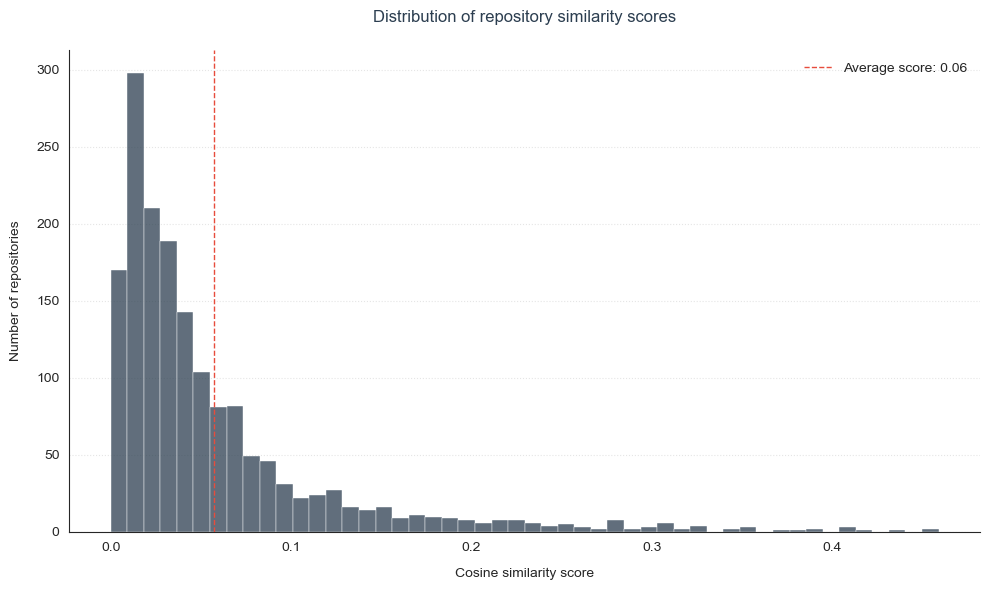

In [13]:
# get basic stats
print("--- Score statistics ---")
print(df_cosine_results['similarity_score'].describe())

# visualize distribution 
sns.set_style("white")
plt.figure(figsize=(10, 6))
sns.histplot(df_cosine_results['similarity_score'], bins=50, color="#2c3e50", edgecolor="white", linewidth=0.3)

# mean line
mean_val = df_cosine_results['similarity_score'].mean()
plt.axvline(mean_val, color='#e74c3c', linestyle='--', linewidth=1, label=f'Average score: {mean_val:.2f}')

sns.despine()

# font weights and titles
plt.title('Distribution of repository similarity scores', fontsize=12, pad=20, color='#2c3e50')
plt.xlabel('Cosine similarity score', fontsize=10, labelpad=10)
plt.ylabel('Number of repositories', fontsize=10, labelpad=10)

# legend and grid
plt.legend(frameon=False, fontsize=10)
plt.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

Should define some threshold to include the ones that are above the threshold for screening. 0.2 could be reasonable.

Or: we could start manually screening from highest to lowest score and stop when for example 5 consecutive repositories do not host covid-related data, and then that's our threshold. 

In [14]:
threshold_high = 0.2
threshold_mid = 0.15

# filter the results
high_confidence_matches = [r for r in cosine_results if r['similarity_score'] >= threshold_high]
mid_confidence_matches = [r for r in cosine_results if r['similarity_score'] >= threshold_mid]

print(f"--- Threshold Analysis (>= {threshold_high}) ---")
print(f"Total candidates found: {len(high_confidence_matches)}")

print(f"--- Threshold Analysis (>= {threshold_mid}) ---")
print(f"Total candidates found: {len(mid_confidence_matches)}")

# print the top ones just to see (0.2 threshold)
''' 
print(f"\n{'Score':<8} | {'Name'}")
print("-" * 50)
for r in high_confidence_matches[:10]: 
    print(f"{r['similarity_score']:.4f}   | {r['repo']}")
'''
# 253 repos with threshold = 0.1 

--- Threshold Analysis (>= 0.2) ---
Total candidates found: 86
--- Threshold Analysis (>= 0.15) ---
Total candidates found: 143


' \nprint(f"\n{\'Score\':<8} | {\'Name\'}")\nprint("-" * 50)\nfor r in high_confidence_matches[:10]: \n    print(f"{r[\'similarity_score\']:.4f}   | {r[\'repo\']}")\n'

**Check self similarity as well!!**

Are the covid repos similar to each other?? Are there any clusters?? 

-> if there's not a "covid cluster", similarity scores don't make sense (I don't think?)

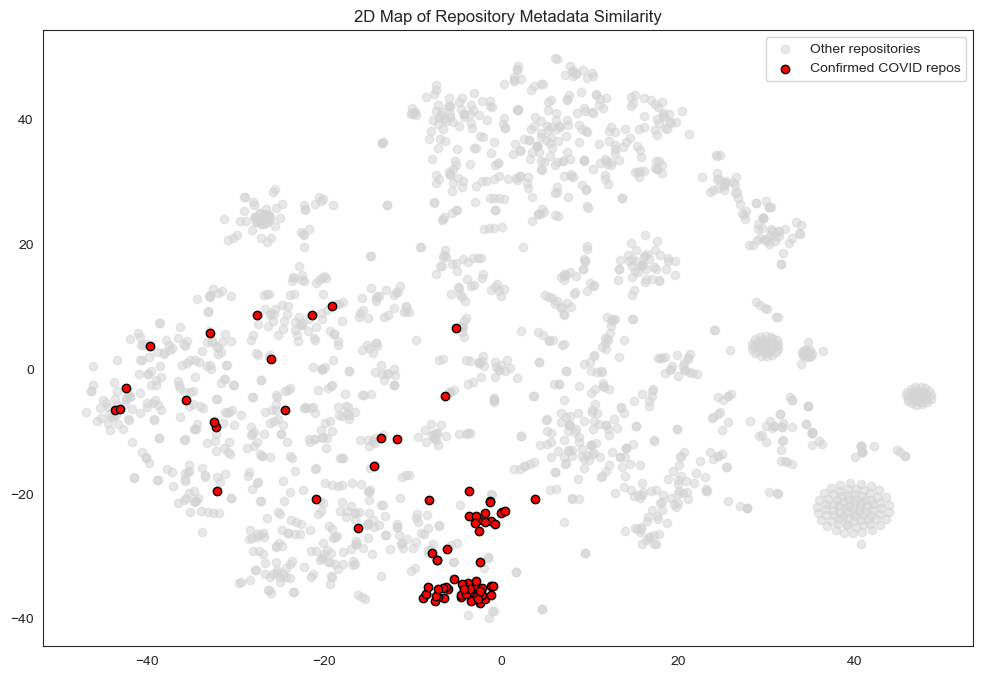

In [15]:
# reduce TF-IDF matrix to 2D
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
vis_dims = tsne.fit_transform(tfidf_matrix.toarray())

# seperate coordinates
x = vis_dims[:, 0]
y = vis_dims[:, 1]

# plot
plt.figure(figsize=(12, 8))
plt.scatter(x, y, c='lightgrey', alpha=0.5, label='Other repositories') # all repos in light gray
plt.scatter(x[covid_indices], y[covid_indices], c='red', edgecolors='black', label='Confirmed COVID repos') # covid repos in red
plt.title('2D Map of Repository Metadata Similarity')
plt.legend()

plt.show()

In [16]:
self_similarity_scores = cosine_similarity(covid_vectors, centroid).flatten()

self_check_df = pd.DataFrame({
    'name': [filtered_repositories[i]['attributes']['name'] for i in covid_indices],
    'score': self_similarity_scores
}).sort_values(by='score', ascending=False)

print(self_check_df.describe())
print("\n--- Top 10 self-similarity ---")
print(self_check_df.head(10))
print("\n--- Bottom 10 self-similarity ---")
print(self_check_df.tail(10))

           score
count  84.000000
mean    0.555532
std     0.223170
min     0.110219
25%     0.380448
50%     0.547593
75%     0.767169
max     0.891225

--- Top 10 self-similarity ---
                                                 name     score
63  FAIRsharing record for: McMaster Multi-Regiona...  0.891225
61          FAIRsharing record for: COVID-19 Registry  0.891225
75  FAIRsharing record for: The COVID-19 and Cance...  0.871057
30  FAIRsharing record for: Pediatric COVID-19 Cas...  0.859775
81  FAIRsharing record for: Global Registry of COV...  0.859775
67  FAIRsharing record for: Psoriasis Patient Regi...  0.844912
25  FAIRsharing record for: Center for Internation...  0.837877
51  FAIRsharing record for: COVID-19 Dermatology r...  0.836792
71  FAIRsharing record for: Pregnancy CoRonavIrus ...  0.831392
39  FAIRsharing record for: Coronavirus and Psoria...  0.814432

--- Bottom 10 self-similarity ---
                                                 name     score
37  FAIRshar

## Extract data & create table with results

In [17]:
def extract_repo_data(item):
    """
    standard extraction of metadata from both 
    direct repo objects and similarity-wrapped objects.
    """

    # check if this is a similarity match (has 'repo' key) or direct
    if isinstance(item, dict) and 'repo' in item:
        rec = item['repo']
        score = round(item.get('similarity_score', 0), 4)
    else:
        rec = item
        score = None # confirmed COVID repos don't need a score
        
    attrs = rec.get("attributes", {})
    meta = attrs.get("metadata", {})
    
    # funders: look for items where the relation is 'funds'
    grants_list = attrs.get("grants", [])
    funder_names = []
    funder_types = []
    for g in grants_list:
        state = g.get("saved_state", {})
        if state.get("relation") == "funds":
            funder_names.append(state.get("name", "N/A"))
            funder_types.append(", ".join(state.get("types", [])))
            
    # publications: look for dois only
    pubs_list = attrs.get("publications", [])
    dois = [p.get("doi") for p in pubs_list if p.get("doi")]

    # contacts: name and email
    contacts_list = meta.get("contacts", [])
    c_names = [c.get('contact_name') for c in contacts_list if c.get('contact_name')]
    c_emails = [c.get('contact_email') for c in contacts_list if c.get('contact_email')]

    
    row = {
        "name": meta.get("name"),
        "homepage": meta.get("homepage"),
        "description": meta.get("description"),
        "status": meta.get("status"),
        "abbreviation": attrs.get("abbreviation"),
        "countries": ", ".join(attrs.get("countries", [])) if attrs.get("countries") else None,
        "year_created": meta.get("year_creation"),
        "funder": "; ".join(funder_names) if funder_names else None,
        "funder_type": "; ".join(set(funder_types)) if funder_types else None, # set() removes duplicates
        "contact_name": "; ".join(c_names) if c_names else None,
        "contact_email": "; ".join(c_emails) if c_emails else None,
        "data_access_condition": (meta.get("data_access_condition") or {}).get("type"),
        "publications": "; ".join(dois) if dois else None
    }


    # for confidence matches only
    if score is not None:
        return {"similarity_score": score, **row}
    
    return row


df_covid = pd.DataFrame([extract_repo_data(r) for r in covid_repositories])
df_high_conf = pd.DataFrame([extract_repo_data(r) for r in high_confidence_matches])
df_mid_conf = pd.DataFrame([extract_repo_data(r) for r in mid_confidence_matches])

# fix year problem
for df in [df_covid, df_high_conf, df_mid_conf]:
    if 'year_created' in df.columns:
        df['year_created'] = (
            pd.to_numeric(df['year_created'], errors='coerce')
            .fillna(0)
            .astype(int)
            .replace(0, "")
        )

df_covid.head()


,name,homepage,description,status,abbreviation,countries,year_created,funder,funder_type,contact_name,contact_email,data_access_condition,publications
0,Antibody Registry,https://antibodyregistry.org/,The Antibody Registry exists to give researche...,ready,None,United States,2009,National Institutes of Health (NIH) Blueprint ...,Government body,Anita Bandrowski,abandrowski@ucsd.edu,open,10.1038/nmeth.2570; 10.1093/nar/gkac927
1,BioData.pt Data Management Portal,https://dmportal.biodata.pt/,The BioData.pt Data Management Portal (DMPorta...,ready,DMPortal,Portugal,2020,None,None,DMPortal Team,dmportal@biodata.pt,open,None
2,Canadian VirusSeq Data Portal,https://virusseq-dataportal.ca/,The goal of the CanCOGeN VirusSeq project is t...,ready,CVDP,Canada,2022,"Genome Canada, Canada; Government of Canada",Government body,General contact,info@virusseq-dataportal.ca,open,None
3,Translational Data Catalog,https://datacatalog.elixir-luxembourg.org/,The Translational Data Catalog is a collection...,ready,IMI Data Catalog,Luxembourg,2016,ELIXIR Luxembourg; European Commision,Government body; Undefined,General contact,data-catalog@elixir-luxembourg.org,open,None
4,BioExcel - Covid19,https://bioexcel-cv19.bsc.es/#/,BioExcel-CV19 is a platform designed to provid...,ready,None,Spain,2020,Human Brain Project; BioExcel CoE; EBRAINS AIS...,Government body; Consortium,Dani Beltrán,daniel.beltran@irbbarcelona.org,open,10.1093/nar/gkad991


In [18]:
df_covid.to_csv("output/fairsharing_covid_repos.csv", index=False)
df_high_conf.to_csv("output/fairsharing_similarity_0.2.csv", index=False)
df_mid_conf.to_csv("output/fairsharing_similarity_0.15.csv", index=False)

In [19]:
# create a mapping of FAIRsharing repo names to their re3data IDs
fs_to_re3_mapping = {}

for rec in covid_repositories:
    repo_name = rec['attributes'].get('metadata', {}).get('name', [])
    cross_refs = rec['attributes'].get('metadata', {}).get('cross_references', [])
    
    for ref in cross_refs:
        # check if 're3data' is mentioned in the name or portal field
        ref_name = ref.get('name', '')
        if 're3data' in ref_name.lower() or 're3data' in ref.get('portal', '').lower():
            # extract just the ID 
            re3_id = ref_name.split(':')[-1] if ':' in ref_name else ref_name
            fs_to_re3_mapping[repo_name] = re3_id


print(f"Found {len(fs_to_re3_mapping)} repositories with re3data cross-references:")
for name, rid in fs_to_re3_mapping.items():
    print(f"- {name}: {rid}")

Found 35 repositories with re3data cross-references:
- Antibody Registry: r3d100010408
- Canadian VirusSeq Data Portal: r3d100013955
- BBMRI-ERIC Directory: r3d100013028
- Image Data Resource : r3d100012435
- bio.tools: r3d100013668
- Medical Imaging and Data Resource Center: r3d100014283
- Sequence Read Archive: r3d100010775
- Immunology Database and Analysis Portal: r3d100012529
- BioSamples: r3d100012628
- TARKI Data Archive: r3d100010496
- Ensembl: r3d100010228
- NCBI Genetic Sequence Database: r3d100010528
- European Centre for Disease Prevention and Control: r3d100013304
- Infectious Diseases Data Observatory: r3d100013358
- CITF DATA PORTAL: r3d100014306
- Novartis Clinical Trial Results Database: r3d100013312
- Humanitarian Data Exchange: r3d100013193
- National Institute of Health - National COVID Cohort Collaborative: r3d100013422
- European Mouse Mutant Archive: r3d100013578
- Arca Dados: r3d100013904
- The Network Data Exchange: r3d100012690
- Better Outcomes Registry & Net

# re3data

In [20]:
with open("data/re3data_all_records.json", "r") as f:
    re3_all_records = json.load(f)

In [21]:
# helper function to print xml
def print_structure(element, level=0):
    indent = "  " * level
    # strip namespace
    tag = element.tag.split('}')[-1] 
    
    text = element.text.strip() if element.text else ""
    if text:
        # increased limit for better reading
        print(f"{indent}<{tag}>: {text[:70]}{'...' if len(text)>70 else ''}")
    else:
        print(f"{indent}<{tag}>")
        
    for child in element:
        print_structure(child, level + 1)

In [22]:
first_record_xml = re3_all_records[0]
root = ET.fromstring(first_record_xml)

print_structure(root)

<re3data>
  <repository>
    <re3data.orgIdentifier>: r3d100000001
    <repositoryName>: Odum Institute Archive Dataverse
    <repositoryURL>: https://dataverse.unc.edu/dataverse/odum
    <description>: The Odum Institute Archive Dataverse contains social science data cura...
    <repositoryContact>: https://uncch-rdmc.atlassian.net/servicedesk/customer/portal/4
    <repositoryContact>: odumarchive@unc.edu
    <type>: disciplinary
    <size>: 13 dataverses, 3.381 datasets, 25.713 files
    <repositoryLanguage>: eng
    <subject>: 1 Humanities and Social Sciences
    <subject>: 111 Social Sciences
    <subject>: 11104 Political Science
    <subject>: 112 Economics
    <subject>: 12 Social and Behavioural Sciences
    <missionStatementURL>: https://odum.unc.edu/archive/
    <contentType>: Databases
    <contentType>: Plain text
    <contentType>: Scientific and statistical data formats
    <contentType>: Standard office documents
    <contentType>: other
    <providerType>: dataProvider


In [23]:
# filtering for covid
# looked through subject 2 == life science
covid_keywords = ['covid', 'sars-cov', 'coronavirus', 'coronaviridae', 'ncov']
re3_covid = []

for xml_text in re3_all_records:
    root = ET.fromstring(xml_text)
    
    subjects = [s.text for s in root.findall(".//{*}subject") if s.text]
    is_life_science = any(s.startswith('2') for s in subjects)
    
    if is_life_science:
        name = root.find(".//{*}repositoryName").text if root.find(".//{*}repositoryName") is not None else ""
        desc = root.find(".//{*}description").text if root.find(".//{*}description") is not None else ""
        keywords = [k.text for k in root.findall(".//{*}keyword") if k.text]
        
        full_text_blob = (name + " " + desc + " " + " ".join(keywords)).lower()
        
        if any(key in full_text_blob for key in covid_keywords):
            repo_id = root.find(".//{*}re3data.orgIdentifier").text
            # save xml so can inspect later
            re3_covid.append({
                "id": repo_id,
                "name": name,
                "subjects": subjects,
                "raw_xml": xml_text 
            })

print(f"Found {len(re3_covid)} potential COVID repositories in the Life Sciences.")

Found 73 potential COVID repositories in the Life Sciences.


In [24]:
# look at subjects 
subject_counts = {}
for record in re3_covid:
    subjects = record.get('subjects', [])
    if subjects:
        # sort by code length to find the most specific one
        sorted_subjects = sorted(subjects, key=lambda s: len(s.split(' ')[0]), reverse=True)
        most_specific = sorted_subjects[0]
        subject_counts[most_specific] = subject_counts.get(most_specific, 0) + 1

print("\n--- Breakdown of repositories by subject ---")
for sub, count in sorted(subject_counts.items(), key=lambda item: item[1], reverse=True):
    print(f"{sub}: {count} repositories")


--- Breakdown of repositories by subject ---
20501 Epidemiology, Medical Biometry, Medical Informatics: 12 repositories
20404 Virology: 10 repositories
20105 General Genetics: 8 repositories
20101 Biochemistry: 7 repositories
20103 Cell Biology: 5 repositories
1 Humanities and Social Sciences: 5 repositories
20107 Bioinformatics and Theoretical Biology: 3 repositories
20509 Pharmacology: 3 repositories
22 Medicine: 3 repositories
204 Microbiology, Virology and Immunology: 2 repositories
201 Basic Biological and Medical Research: 2 repositories
20502 Public Health, Health Services Research, Social Medicine: 2 repositories
20403 Medical Microbiology, Molecular Infection Biology: 2 repositories
20306 Animal Genetics, Cell and Developmental Biology: 1 repositories
20104 Structural Biology: 1 repositories
20510 Toxicology and Occupational Medicine: 1 repositories
20606 Cognitive Neuroscience and Neuroimaging: 1 repositories
20532 Biomedical Technology and Medical Physics: 1 repositories
10

In [ ]:
# inspect a record
'''
if re3_covid:
    print("\n--- SAMPLE COVID RECORD ---")
    sample_xml = re3_covid[5]['raw_xml'] 
    sample_root = ET.fromstring(sample_xml)
    print_structure(sample_root)
'''


--- SAMPLE COVID RECORD ---
<re3data>
  <repository>
    <re3data.orgIdentifier>: r3d100010449
    <repositoryName>: Canada's Michael Smith Genome Sciences Centre
    <additionalName>: GSC
    <repositoryURL>: https://www.bcgsc.ca/
    <description>: We are a leading international centre for genomics and bioinformatics ...
    <repositoryContact>: https://www.bcgsc.ca/contact-us
    <repositoryContact>: info@bcgsc.ca
    <type>: disciplinary
    <size>
    <startDate>: 1999-01-01
    <repositoryLanguage>: eng
    <subject>: 2 Life Sciences
    <subject>: 201 Basic Biological and Medical Research
    <subject>: 204 Microbiology, Virology and Immunology
    <subject>: 205 Medicine
    <subject>: 20501 Epidemiology, Medical Biometry, Medical Informatics
    <subject>: 21 Biology
    <subject>: 22 Medicine
    <missionStatementURL>: https://www.bcgsc.ca/about-us
    <contentType>: Images
    <contentType>: Scientific and statistical data formats
    <contentType>: Standard office document

In [ ]:
'''
print("\n--- CHECKING HUMANITIES/SOCIAL SCIENCE MATCHES ---")
count = 0
for record in re3_covid:
    # check if 'most specific' subject starts with '1'
    subjects = record.get('subjects', [])
    sorted_subjects = sorted(subjects, key=lambda s: len(s.split(' ')[0]), reverse=True)
    
    if sorted_subjects and sorted_subjects[0].startswith('1'):
        count += 1
        print(f"\n[{count}] Name: {record['name']}")
        print(f"All Subjects: {subjects}")
        
        sample_root = ET.fromstring(record['raw_xml'])
        print_structure(sample_root)
'''


--- CHECKING HUMANITIES/SOCIAL SCIENCE MATCHES ---

[1] Name: European Union Open Data Portal
All Subjects: ['1 Humanities and Social Sciences', '2 Life Sciences', '3 Natural Sciences', '4 Engineering Sciences']
<re3data>
  <repository>
    <re3data.orgIdentifier>: r3d100011728
    <repositoryName>: European Union Open Data Portal
    <additionalName>: EU ODP
    <additionalName>: EU Open Data Portal
    <repositoryURL>: https://data.europa.eu/data/datasets
    <repositoryIdentifier>: 10.25504/FAIRsharing.d7b57d
    <repositoryIdentifier>: 2315-3091
    <description>: The European Union Open Data Portal is the single point of access to a...
    <repositoryContact>: https://data.europa.eu/de/feedback/form
    <type>: disciplinary
    <size>: 1.588.520 datasets; 181 catalogs
    <startDate>: 2012-12
    <repositoryLanguage>: bul
    <repositoryLanguage>: ces
    <repositoryLanguage>: dan
    <repositoryLanguage>: deu
    <repositoryLanguage>: ell
    <repositoryLanguage>: eng
    <repos